# Martini Pioniers Training


# Honden vs Katten Herkenning - AI Pioniers Workshop

In deze workshop bouwen we een AI-model dat het verschil kan zien tussen honden en katten.

Je hoeft alleen maar op **Run** te drukken bij elke cel, van boven naar beneden.

**Wat gaan we doen?**
1. Data downloaden
2. Bekijken hoe de afbeeldingen eruitzien
3. Een model trainen
4. Testen hoe goed het werkt
5. Voorspellingen doen op nieuwe afbeeldingen

**Vergelijking met het ziekenhuis:** dit is hetzelfde principe als AI die op medische beelden werkt. Wij classificeren hond of kat — in het ziekenhuis zou je bijvoorbeeld gezond of ziek weefsel classificeren.

## Stap 0: Voorbereiding

We laden de tools die we nodig hebben.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import tarfile
import urllib.request
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Alles is geladen.")

Alles is geladen.


## Stap 1: Data downloaden

We downloaden de Oxford-IIIT Pet Dataset. Dit is een openbare dataset met foto's van 37 rassen honden en katten.

Dit kan even duren (ongeveer 800MB).

In [12]:
url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
annotations_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

if not os.path.exists("images"):
    print("Afbeeldingen downloaden... (dit kan een paar minuten duren)")
    urllib.request.urlretrieve(url, "images.tar.gz")
    with tarfile.open("images.tar.gz", "r:gz") as tar:
        tar.extractall(".")
    os.remove("images.tar.gz")
    print("Download klaar.")
else:
    print("Afbeeldingen waren al gedownload.")

# Bekijk hoeveel bestanden er zijn
all_files = [f for f in os.listdir("images") if f.endswith(".jpg")]
print(f"Aantal afbeeldingen: {len(all_files)}")

Afbeeldingen downloaden... (dit kan een paar minuten duren)
Download klaar.
Aantal afbeeldingen: 7390


## Stap 2: Data klaarmaken

De bestandsnamen bevatten het ras. Als de naam met een hoofdletter begint is het een kat, anders een hond. Bijvoorbeeld:
- `Abyssinian_100.jpg` ? kat
- `beagle_50.jpg` ? hond

We verkleinen elke afbeelding naar 64x64 pixels zodat het model er snel mee kan werken. Elke afbeelding wordt zo een rijtje van 64 x 64 x 3 = 12.288 getallen (pixels).

In [18]:
IMAGE_SIZE = 64
MAX_PER_CLASS = 500  # We gebruiken max 500 katten en 500 honden zodat het snel gaat

images = []
labels = []
filenames = []

cat_count = 0
dog_count = 0

for filename in sorted(os.listdir("images")):
    if not filename.endswith(".jpg"):
        continue

    # Hoofdletter = kat, kleine letter = hond
    is_cat = filename[0].isupper()

    if is_cat and cat_count >= MAX_PER_CLASS:
        continue
    if not is_cat and dog_count >= MAX_PER_CLASS:
        continue

    try:
        img = Image.open(os.path.join("images", filename)).convert("RGB")
        img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
        img_array = np.array(img).flatten()  # Maak er een plat rijtje getallen van

        images.append(img_array)
        labels.append(0 if is_cat else 1)
        filenames.append(filename)

        if is_cat:
            cat_count += 1
        else:
            dog_count += 1
    except:
        continue

    if cat_count >= MAX_PER_CLASS and dog_count >= MAX_PER_CLASS:
        break

X = np.array(images)
y = np.array(labels)

print(f"Dataset klaar: {len(X)} afbeeldingen")
print(f"  Katten: {sum(y == 0)}")
print(f"  Honden: {sum(y == 1)}")
print(f"  Elke afbeelding is {IMAGE_SIZE}x{IMAGE_SIZE} pixels = {X.shape[1]} getallen")

Dataset klaar: 1000 afbeeldingen
  Katten: 500
  Honden: 500
  Elke afbeelding is 64x64 pixels = 12288 getallen


## Stap 3: De data bekijken

Laten we een paar voorbeelden bekijken. Het is altijd belangrijk om je data te bekijken voordat je een model traint.

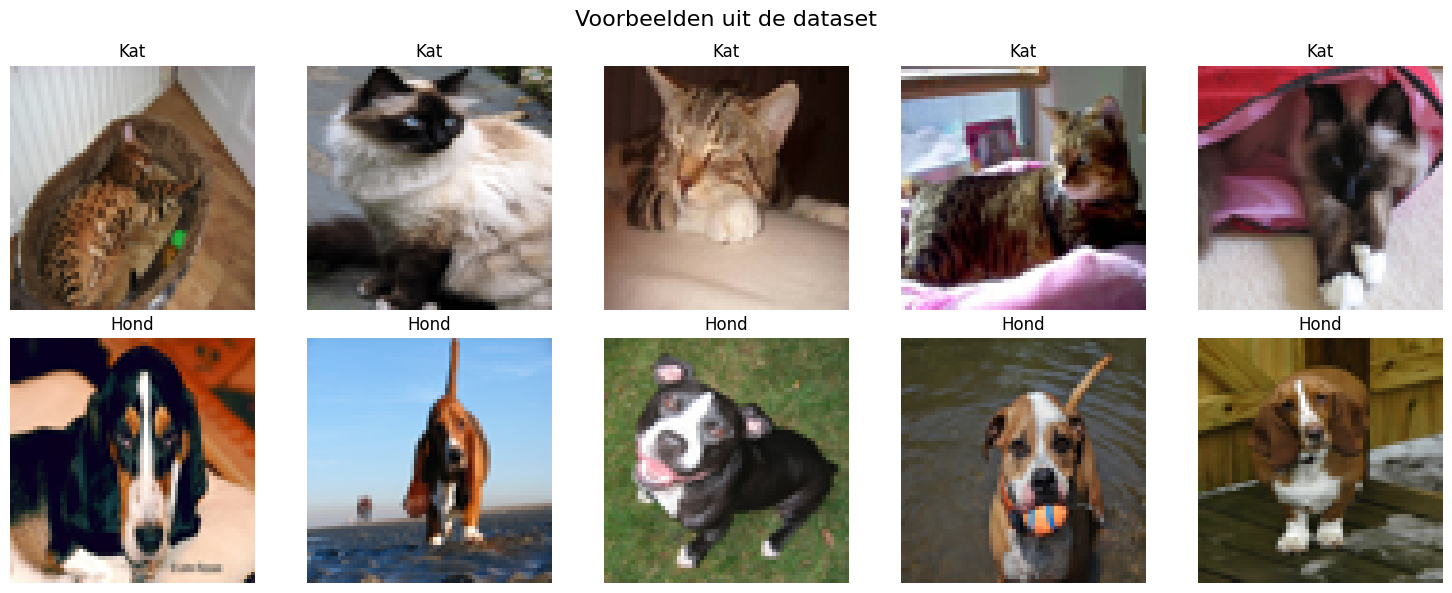

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Voorbeelden uit de dataset", fontsize=16)

# 5 katten en 5 honden
cat_indices = np.where(y == 0)[0]
dog_indices = np.where(y == 1)[0]

for i in range(5):
    # Kat
    idx = cat_indices[np.random.randint(len(cat_indices))]
    img = X[idx].reshape(IMAGE_SIZE, IMAGE_SIZE, 3)
    axes[0, i].imshow(img)
    axes[0, i].set_title("Kat")
    axes[0, i].axis("off")

    # Hond
    idx = dog_indices[np.random.randint(len(dog_indices))]
    img = X[idx].reshape(IMAGE_SIZE, IMAGE_SIZE, 3)
    axes[1, i].imshow(img)
    axes[1, i].set_title("Hond")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Stap 4: Data splitsen

We verdelen de data in twee delen:
- **Trainingsdata** (80%): hier leert het model van
- **Testdata** (20%): hier testen we hoe goed het model werkt op nieuwe afbeeldingen

Dit is belangrijk: als je test op dezelfde data als waarmee je traint, weet je niet of het model echt iets geleerd heeft of alleen maar uit het hoofd heeft geleerd.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Trainingsdata: {len(X_train)} afbeeldingen")
print(f"Testdata:      {len(X_test)} afbeeldingen")

Trainingsdata: 800 afbeeldingen
Testdata:      200 afbeeldingen


## Stap 5: Het model trainen

We gebruiken een **Random Forest** model. Dit is een verzameling van beslisbomen die samen stemmen over het antwoord.

Stel je voor: je vraagt 100 artsen om naar een foto te kijken. Elke arts kijkt naar andere kenmerken. De meerderheid beslist of het een hond of kat is. Dat is in essentie hoe een Random Forest werkt.

In [21]:
print("Model aan het trainen...")

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Training voltooid.")

Model aan het trainen...
Training voltooid.


## Stap 6: Resultaten bekijken

We testen het model op de testdata: afbeeldingen die het model nog nooit gezien heeft.

In [22]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Nauwkeurigheid op testdata: {accuracy:.1%}")
print(f"({sum(y_pred == y_test)} van de {len(y_test)} correct)")

Nauwkeurigheid op testdata: 67.0%
(134 van de 200 correct)


### Confusion Matrix

De confusion matrix laat zien waar het model goed in is en waar het fouten maakt:
- Hoeveel katten zijn correct als kat herkend?
- Hoeveel honden zijn correct als hond herkend?
- Hoeveel katten werden per ongeluk als hond bestempeld (en andersom)?

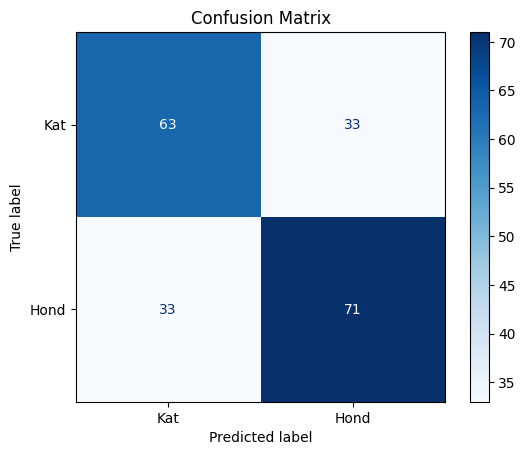

In [23]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Kat", "Hond"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Stap 7: Voorspellingen bekijken

Laten we een paar voorspellingen van het model bekijken. Groene titels zijn correct, rode zijn fout.

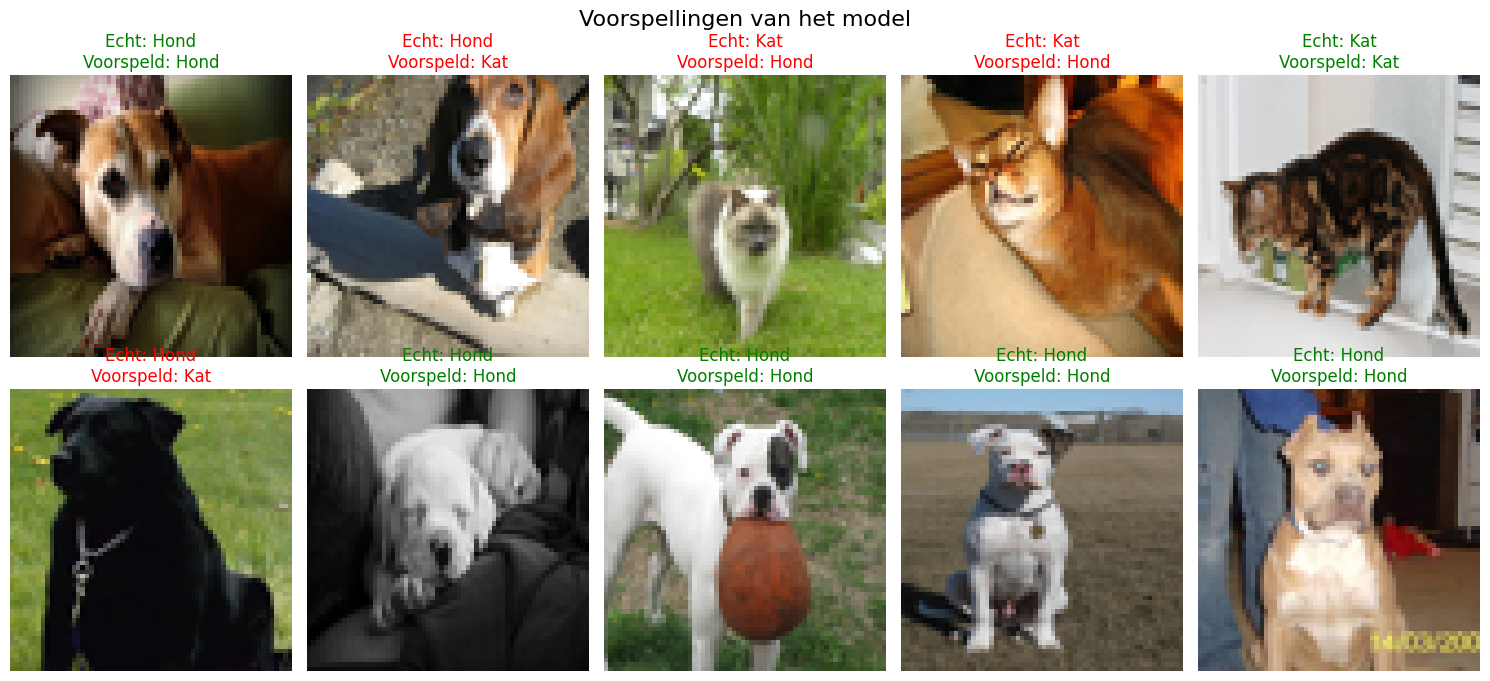

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Voorspellingen van het model", fontsize=16)

label_names = ["Kat", "Hond"]
indices = np.random.choice(len(X_test), 10, replace=False)

for i, idx in enumerate(indices):
    row, col = i // 5, i % 5
    img = X_test[idx].reshape(IMAGE_SIZE, IMAGE_SIZE, 3)

    true_label = label_names[y_test[idx]]
    pred_label = label_names[y_pred[idx]]
    correct = y_test[idx] == y_pred[idx]

    axes[row, col].imshow(img)
    color = "green" if correct else "red"
    axes[row, col].set_title(f"Echt: {true_label}\nVoorspeld: {pred_label}", color=color)
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## Stap 8: Welke pixels zijn belangrijk?

Het Random Forest model geeft aan welke pixels het meest bijdragen aan de beslissing. We kunnen dit visualiseren als een heatmap over de afbeelding.

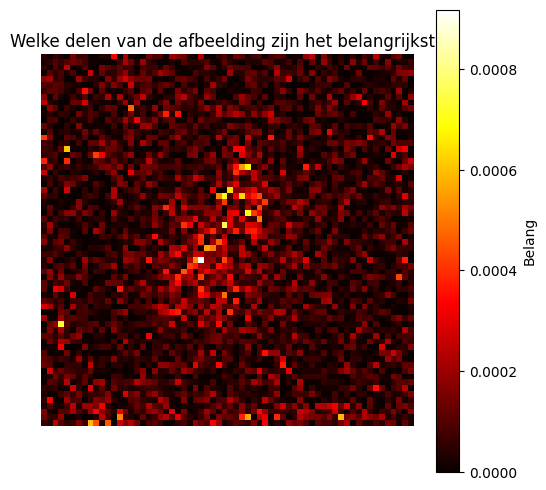

In [25]:
importances = model.feature_importances_
importance_image = importances.reshape(IMAGE_SIZE, IMAGE_SIZE, 3).mean(axis=2)

plt.figure(figsize=(6, 6))
plt.imshow(importance_image, cmap="hot")
plt.colorbar(label="Belang")
plt.title("Welke delen van de afbeelding zijn het belangrijkst?")
plt.axis("off")
plt.show()

## Samenvatting

We hebben vandaag:
1. Een dataset met honden- en kattenfoto's gedownload
2. De afbeeldingen omgezet naar getallen (pixels)
3. Een Random Forest model getraind
4. Het model getest op nieuwe afbeeldingen

**Belangrijke inzichten:**
- AI "ziet" een afbeelding als een tabel met getallen (pixelwaarden)
- Het model leert patronen in die getallen die horen bij "hond" of "kat"
- In het ziekenhuis werkt dit hetzelfde: een AI leert patronen in medische beelden die horen bij een bepaalde diagnose
- De kwaliteit van de data is minstens zo belangrijk als het model zelf

**Beperkingen van deze aanpak:**
- We hebben de afbeeldingen sterk verkleind (64x64) waardoor detail verloren gaat
- Een Random Forest op ruwe pixels is niet de beste aanpak voor beeldherkenning
- In de praktijk worden hiervoor neurale netwerken (deep learning) gebruikt die veel beter presteren
- Maar het principe is hetzelfde!